In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [2]:
# read the csv with correct separator
# corect decimal, columns and missing values interpretation
data = pd.read_csv('E:/school/Masterat/Calcul Neuronal/LSTM_air_prediction/dataset/Amazon_stock_data.csv')

# use the gpu if available
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

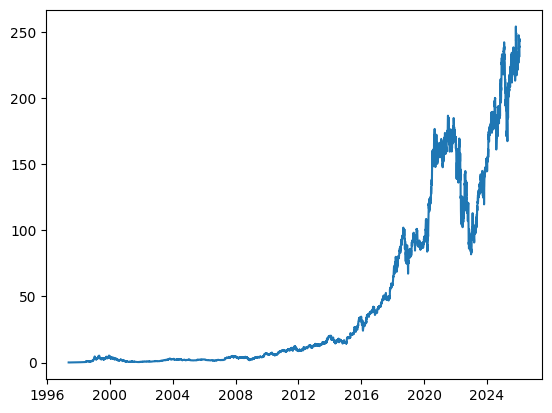

In [3]:
# handle the date column
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').reset_index(drop=True)

plt.plot(data['Date'], data['Close'])
plt.show()

In [4]:
from copy import deepcopy as dc

def prepare_dataframe_for_lstm(df: pd.DataFrame, n_steps: int) -> pd.DataFrame:
    df = dc(df)
    # remove all the columns except the Closing Value
    df = df[['Close']]
    df['Close'] = np.log(data['Close'])

    for i in range(1, n_steps+1):
        df[f'Close(t-{i})'] = df['Close'].shift(i)

    df.dropna(inplace=True)

    return df

In [5]:
lookback = 30
shifted_df = prepare_dataframe_for_lstm(data, lookback)

In [6]:
# covert the dataframe to np
shifted_df_as_np = shifted_df.to_numpy()
shifted_df_as_np

array([[-2.59723809, -2.58334452, -2.58334452, ..., -2.46021011,
        -2.44809656, -2.32363512],
       [-2.56287253, -2.59723809, -2.58334452, ..., -2.50383261,
        -2.46021011, -2.44809656],
       [-2.57990764, -2.56287253, -2.59723809, ..., -2.64010185,
        -2.50383261, -2.46021011],
       ...,
       [ 5.47403382,  5.4771328 ,  5.45677304, ...,  5.42137536,
         5.43929595,  5.44578864],
       [ 5.4999512 ,  5.47403382,  5.4771328 , ...,  5.40510683,
         5.42137536,  5.43929595],
       [ 5.49310257,  5.4999512 ,  5.47403382, ...,  5.40519672,
         5.40510683,  5.42137536]], shape=(7191, 31))

In [7]:
# normalize the numpy array
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
shifted_df_as_np = scaler.fit_transform(shifted_df_as_np)
shifted_df_as_np

array([[-1.        , -0.99658407, -0.99658407, ..., -0.95072284,
        -0.94776817, -0.91741013],
       [-0.99155074, -1.        , -0.99658407, ..., -0.96136304,
        -0.95072284, -0.94776817],
       [-0.99573906, -0.99155074, -1.        , ..., -0.99460118,
        -0.96136304, -0.95072284],
       ...,
       [ 0.98443669,  0.98519862,  0.98019288, ...,  0.97171586,
         0.97608696,  0.97767063],
       [ 0.99080884,  0.98443669,  0.98519862, ...,  0.96774771,
         0.97171586,  0.97608696],
       [ 0.98912501,  0.99080884,  0.98443669, ...,  0.96776964,
         0.96774771,  0.97171586]], shape=(7191, 31))

In [8]:
X = shifted_df_as_np[:, 1:] # all the rows, from the second column on to the end
X = dc(np.flip(X, axis=1)) # mirror the data horizontically
Y = shifted_df_as_np[:, 0] # all the rows only the first column

X.shape, Y.shape

((7191, 30), (7191,))

In [9]:
train_split = int(len(X) * 0.70)
test_split = int(len(X) * 0.85)

train_split, test_split

(5033, 6112)

In [10]:
# split the data into train and test groups
X_train = X[:train_split]
X_test  = X[train_split:test_split]
X_val   = X[test_split:]

Y_train = Y[:train_split]
Y_test  = Y[train_split:test_split]
Y_val   = Y[test_split:]

X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((5033, 30), (1079, 30), (5033,), (1079,))

In [11]:
# adding an extra dimension on the matrices for pytorch LSTMS
X_train = X_train.reshape((-1, lookback, 1))
X_test  = X_test.reshape((-1, lookback, 1))
X_val   = X_val.reshape((-1, lookback, 1))

Y_train = Y_train.reshape((-1, 1))
Y_test  = Y_test.reshape((-1, 1))
Y_val   = Y_val.reshape((-1, 1))

X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((5033, 30, 1), (1079, 30, 1), (5033, 1), (1079, 1))

In [12]:
# making this data into tensors for pytorch
X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test  = torch.tensor(X_test).float()
Y_test  = torch.tensor(Y_test).float()
X_val   = torch.tensor(X_val).float()
Y_val   = torch.tensor(Y_val).float()

X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

(torch.Size([5033, 30, 1]),
 torch.Size([1079, 30, 1]),
 torch.Size([5033, 1]),
 torch.Size([1079, 1]))

When training models in pytorch generaly we can use datasets rather than raw tensors
This is the class that creates the DataSets objects

In [ ]:
from torch.utils.data import Dataset

class TimeSeriesDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    # pytorch needs the len and getitem magic methods to train the model
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.Y[index]
    
train_dataset = TimeSeriesDataset(X_train, Y_train)
test_dataset = TimeSeriesDataset(X_test, Y_test)

In [14]:
from torch.utils.data import DataLoader

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [15]:
# inspecting the batch size and dimensions
for _, batch in enumerate(train_loader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)
    break

torch.Size([16, 30, 1]) torch.Size([16, 1])


In [16]:
class LSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_stacked_layers: int):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_stacked_layers,
                            batch_first=True)
        # maps the LSTM output to a single predicted value
        self.fc = nn.Linear(hidden_size, 1) # Input sequence  →  LSTM  →  hidden state (hidden_size)  →  fc  →  prediction (1 value)

    # TODO: Create a stateful training
    def forward(self, x):
        batch_size = x.size(0)
        # initial short-term memory (hidden state)
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)
        # initial long-term memory (cell state)
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)

        (out, (hn, cn)) = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out
    
model = LSTM(1, 64 , 2)
model.to(device)
model

LSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [17]:
def train_one_epoch():
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    # it is a tensor with value
    running_loss = 0.0

    for batch_index, batch in enumerate(train_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        output = model(x_batch)
        loss = loss_function(output, y_batch)
        running_loss += loss.item()
        # returns the gradients to 0
        optimizer.zero_grad()
        # do a backward probagation throug the loss to calculate the gradient
        loss.backward()
        # take a step into the direction of the gradient
        optimizer.step()

        if batch_index % 100 == 99: # print every 100 batches
            avg_loss_across_batches = running_loss / 100
            print(f'Batch {batch_index+1}, Average Loss: {avg_loss_across_batches:.3f}')
            running_loss = 0.0
    print()

In [18]:
def validate_one_epoch():
    # put the model in evaluation mode
    model.train(False)
    running_loss = 0.0

    for batch_index, batch in enumerate(test_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        with torch.no_grad():
            output = model(x_batch)
            loss = loss_function(output, y_batch)
            running_loss += loss.item()

    avg_loss_across_batches = running_loss / len(test_loader)

    print(f'Val Loss: {avg_loss_across_batches:.3f}')
    print("*******************************************")
    print()

In [19]:
learning_rate = 0.001
num_epochs = 20
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    train_one_epoch()
    validate_one_epoch()

Epoch: 1
Batch 100, Average Loss: 0.086
Batch 200, Average Loss: 0.007
Batch 300, Average Loss: 0.003

Val Loss: 0.030
*******************************************

Epoch: 2
Batch 100, Average Loss: 0.112
Batch 200, Average Loss: 0.007
Batch 300, Average Loss: 0.005

Val Loss: 0.008
*******************************************

Epoch: 3
Batch 100, Average Loss: 0.075
Batch 200, Average Loss: 0.002
Batch 300, Average Loss: 0.000

Val Loss: 0.000
*******************************************

Epoch: 4
Batch 100, Average Loss: 0.030
Batch 200, Average Loss: 0.002
Batch 300, Average Loss: 0.000

Val Loss: 0.000
*******************************************

Epoch: 5
Batch 100, Average Loss: 0.019
Batch 200, Average Loss: 0.001
Batch 300, Average Loss: 0.000

Val Loss: 0.000
*******************************************

Epoch: 6
Batch 100, Average Loss: 0.015
Batch 200, Average Loss: 0.001
Batch 300, Average Loss: 0.000

Val Loss: 0.001
*******************************************

Epoch: 7
Batch 1

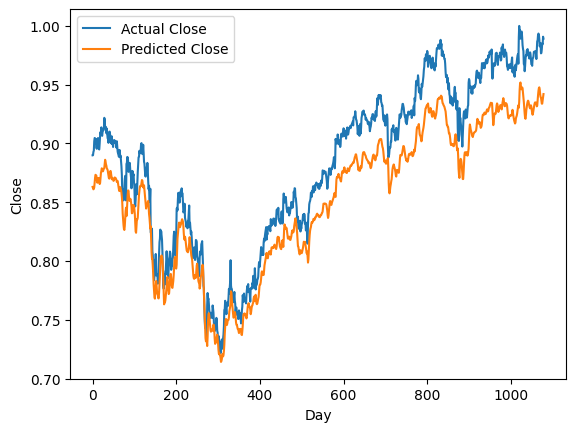

In [20]:
# plot the actual value vs the predicted values
with torch.no_grad():
    predicted = model(X_val.to(device)).to('cpu').numpy()

plt.plot(Y_val, label='Actual Close')
plt.plot(predicted, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()